# Project Goal: To find out if there is a better lifetsyle that reduces chance of getting IBD.


**Background and Motivation:** 
Inflammatory Bowel Disease (IBD) is a chronic inflammation in our gastrointestinal(GI) tract that cannot be cured. It's symptoms may come in sudden flares which include intense stomach cramps, diarrhea, among other issues. I have personally noticed that my digestion and bowel habits seemed to fluctuate during times of high stress, exercise frequency, or shifts in my physical activity. This led me to wonder if lifestyle factors both mentally and physically might be associated with longer term GI outcomes such as IBD. While my own observations are individual and anecdoctal, there are scientific discussions suggesting links between gut environment and lifestyle. 

This project explores the associations between lifestyle factors and IBD prevalence. 

Specifically, the analysis will focus on the following attributes in this dataset: 
- Physical lifetyle: Physical_Activity
- Mental Lifetsyle: Stress_Level
- Genetic Predisposition: Genetic_Markers


These factors are examined in relation to: 
- Colonoscopy_Result, where
  - 1 = Presence of IBD
  - 0 = Absence of IBD

In [174]:
!pip install pandas
!pip install seaborn
!pip install matplotlib.pyplot

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Loading Dataset

I will be using the Gastrointestinal Disease Dataset for this project. It is retrieved from Kaggle, https://www.kaggle.com/datasets/amanik000/gastrointestinal-disease-dataset

In [176]:
df = pd.read_csv("gastrointestinal_disease.csv")
print("\nData preview:")
display(df.head())


Data preview:


,Age,Gender,BMI,Body_Weight,Obesity_Status,Ethnicity,Family_History,Genetic_Markers,Microbiome_Index,Autoimmune_Disorders,...,Rectal_Bleeding,Appetite_Loss,Weight_Loss,Bowel_Habits,Bowel_Movement_Frequency,NSAID_Use,Antibiotic_Use,PPI_Use,Medications,Disease_Class
0,9,Female,19.1,44.1,Normal,Black,0,9,0.25,1,...,1,1,1,Irregular,5,0,0,0,1,Unexplained weight loss
1,78,Male,38.2,121.0,Obese,White,1,10,0.27,1,...,0,1,0,Normal,4,0,1,1,1,Blood in stool
2,20,Male,34.2,79.0,Obese,Black,1,6,0.83,0,...,0,0,0,Frequent,0,1,0,0,0,Nausea or vomiting
3,73,Female,30.8,68.4,Obese,Asian,0,1,0.67,0,...,0,1,0,Infrequent,2,0,1,0,1,Nausea or vomiting
4,58,Male,26.4,66.7,Overweight,White,0,1,0.84,1,...,0,1,0,Normal,4,0,0,1,1,Unexplained weight loss


In [177]:
print("\nInfo:")
print(df.info())
print("\nshape:")
print(df.shape)

df.describe(include='all')


Info:
<class 'pandas.DataFrame'>
RangeIndex: 30560 entries, 0 to 30559
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       30560 non-null  int64  
 1   Gender                    30560 non-null  str    
 2   BMI                       30560 non-null  float64
 3   Body_Weight               30560 non-null  float64
 4   Obesity_Status            30560 non-null  str    
 5   Ethnicity                 30560 non-null  str    
 6   Family_History            30560 non-null  int64  
 7   Genetic_Markers           30560 non-null  int64  
 8   Microbiome_Index          30560 non-null  float64
 9   Autoimmune_Disorders      30560 non-null  int64  
 10  H_Pylori_Status           30560 non-null  int64  
 11  Fecal_Calprotectin        30560 non-null  int64  
 12  Occult_Blood_Test         30560 non-null  int64  
 13  CRP_ESR                   30560 non-null  float64
 14  Endoscopy_

,Age,Gender,BMI,Body_Weight,Obesity_Status,Ethnicity,Family_History,Genetic_Markers,Microbiome_Index,Autoimmune_Disorders,...,Rectal_Bleeding,Appetite_Loss,Weight_Loss,Bowel_Habits,Bowel_Movement_Frequency,NSAID_Use,Antibiotic_Use,PPI_Use,Medications,Disease_Class
count,30560.000000,30560,30560.000000,30560.000000,30560,30560,30560.000000,30560.000000,30560.000000,30560.000000,...,30560.000000,30560.000000,30560.000000,30560,30560.000000,30560.000000,30560.000000,30560.000000,30560.000000,30560
unique,NaN,2,NaN,NaN,4,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,6
top,NaN,Female,NaN,NaN,Obese,White,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Frequent,NaN,NaN,NaN,NaN,NaN,Abdominal cramps or pain
freq,NaN,16010,NaN,NaN,12806,12291,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7747,NaN,NaN,NaN,NaN,NaN,5243
mean,47.220124,NaN,27.987513,72.600435,NaN,NaN,0.499738,4.987958,0.502110,0.495353,...,0.503730,0.499018,0.500916,NaN,5.026211,0.498168,0.500851,0.506217,0.501178,NaN
std,24.923513,NaN,6.958877,24.121179,NaN,NaN,0.500008,3.177955,0.288707,0.499987,...,0.499994,0.500007,0.500007,NaN,3.159638,0.500005,0.500007,0.499970,0.500007,NaN
min,5.000000,NaN,16.000000,27.200000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,26.000000,NaN,21.900000,54.200000,NaN,NaN,0.000000,2.000000,0.250000,0.000000,...,0.000000,0.000000,0.000000,NaN,2.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,47.000000,NaN,27.900000,69.200000,NaN,NaN,0.000000,5.000000,0.500000,0.000000,...,1.000000,0.000000,1.000000,NaN,5.000000,0.000000,1.000000,1.000000,1.000000,NaN
75%,69.000000,NaN,34.100000,88.500000,NaN,NaN,1.000000,8.000000,0.750000,1.000000,...,1.000000,1.000000,1.000000,NaN,8.000000,1.000000,1.000000,1.000000,1.000000,NaN


# 2) Exploratory Data Analysis 

In [178]:
factors = ['Physical_Activity', 'Stress_Level', 'Genetic_Markers', 'Colonoscopy_Result']

for f in factors:
    s = pd.to_numeric(df[f], errors='coerce').dropna()
    
    print(f"\nStatistics for {f}:")
    print(f"Series length after dropping NaNs: {len(s)}")
    
    if len(s) > 0:
        print("Min/Max:", float(s.min()), float(s.max()))
        print("Mean/Std:", float(s.mean()), float(s.std(ddof=1)))
    else:
        print("No valid numeric data.")


Statistics for Physical_Activity:
Series length after dropping NaNs: 30560
Min/Max: 0.0 7.0
Mean/Std: 3.4782395287958114 2.283625586457919

Statistics for Stress_Level:
Series length after dropping NaNs: 30560
Min/Max: 1.0 10.0
Mean/Std: 5.474574607329843 2.871828388695283

Statistics for Genetic_Markers:
Series length after dropping NaNs: 30560
Min/Max: 0.0 10.0
Mean/Std: 4.987958115183246 3.1779553380198537

Statistics for Colonoscopy_Result:
Series length after dropping NaNs: 30560
Min/Max: 0.0 1.0
Mean/Std: 0.49106675392670157 0.4999283702683108


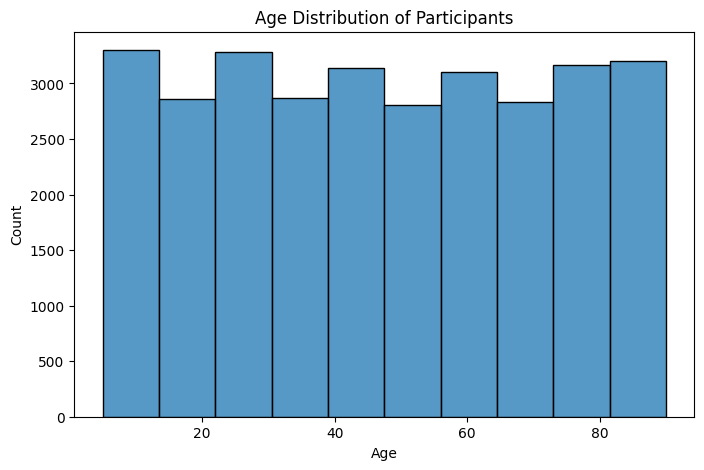

In [179]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', bins=10) 
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution of Participants')
plt.show()

This graph shows a relatively even distribution of participants across all age groups, reducing the risk of age-related sampling bias in the analysis. 

# 3) Visualisations

A) Let us examine how physical lifestyles are associated with the presence of IBD with **Physical_Activity**

**Physical_Activity** is indicated by levels from 0 to 7. 

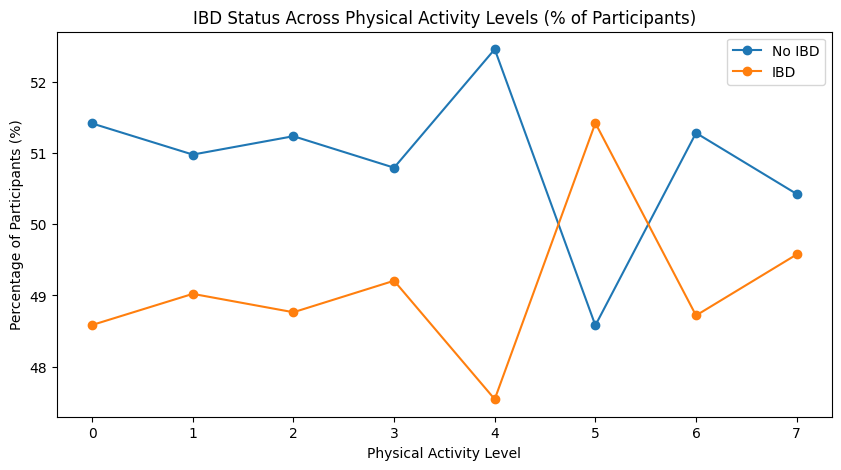

In [180]:
counts = df.groupby(['Physical_Activity', 'Colonoscopy_Result']).size().unstack(fill_value=0)

percentages = counts.div(counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,5))
plt.plot(percentages.index, percentages[0], marker='o', label='No IBD')
plt.plot(percentages.index, percentages[1], marker='o', label='IBD')

plt.xlabel('Physical Activity Level')
plt.ylabel('Percentage of Participants (%)')
plt.title('IBD Status Across Physical Activity Levels (% of Participants)')
plt.legend()
plt.show()

The percentage of participants with IBD generally increase as physical activity level increases, while the percentage of participants without IBD generally decrease as physical activity level increases. Notably, when physical activity level increases from 3 and 4, there is a steep increase in the non-IBD group and a corresponding steep decrease in the IBD group. Overall, the trends of the two groups move in opposite directions across different physical activity levels, with the steepest changes occurring between levels 3 and 6. Outside of this range, there are smaller, gradual fluctuations in both groups.

These trends may suggest an association between physical activity and GI disease status. Higher levels of physical activity appear linked to a greater proportion of participants with IBD in this dataset, whereas lower activity levels are more common among participants without IBD. However, this observation does not imply causation, and further studies would be needed to understand underlying biological or behavioral mechanisms. 

I chose line graph as it allows easier visualisation of fluctuations in trends. 

Limitation: Line graph can exaggerate trends when sample sizes are small at certain levels, making steep increases or decreases appear more significant than they actually are and potentially misleading interpretation of patterns.

B) Let us examine how mental lifestyles are associated with the presence of IBD with **Stress_Level**

**Stress_Level** is indicated by levels from 0 to 10. 

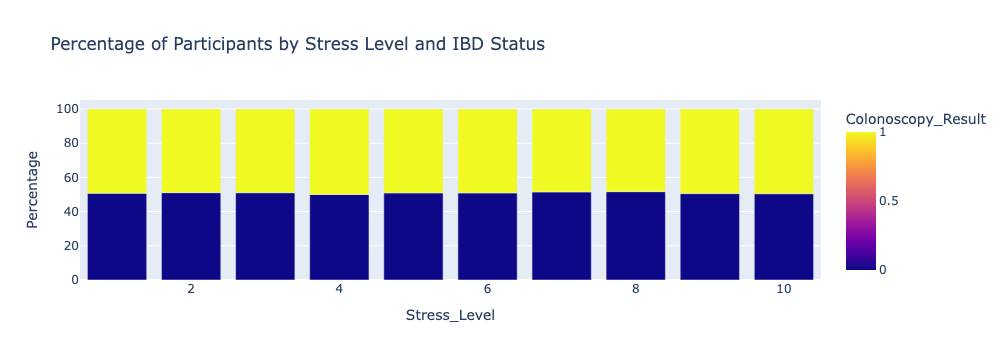

In [184]:
import plotly.express as px

counts = df.groupby(['Stress_Level', 'Colonoscopy_Result']).size().reset_index(name='Count')

counts['Percentage'] = counts.groupby('Stress_Level')['Count'].transform(lambda x: x / x.sum() * 100)

fig = px.bar(
    counts,
    x='Stress_Level',
    y='Percentage',
    color='Colonoscopy_Result',
    barmode='stack',              
    title='Percentage of Participants by Stress Level and IBD Status',
    hover_data={'Percentage': ':.1f'}
)

fig.show()

The stacked bar graph shows the percentage of participants with and without IBD across different stress levels. Overall, the percentages remain fairly consistent across stress levels, with only minor fluctuations. This suggests that, in this dataset, stress level does not appear to be strongly associated with the presence of IBD.

I chose to use stacked bar plot as it allows us to visualise the proportion of participants with and without IBD within each stress level, allowing easy comparison of relative percentages across stress levels. By stacking the bars, we can easily compare the proportion of IBD and non-IBD participants for each stress level while keeping all information in a single bar per category.

Limittaion: Stacked bar graph using percentage cause readability issues when the percentage remains relatively uniform. It is slightly worse for comparison than bar graph places side-by-side. 

C) Let us examine how physical lifestyles are associated with the presence of IBD with **Genetic_Markers**

**Genetic_Markers** is indicated by levels from 0 to 10. It represents the presence of known genetic markers associated with disease risk, from lowest to highest risk. 

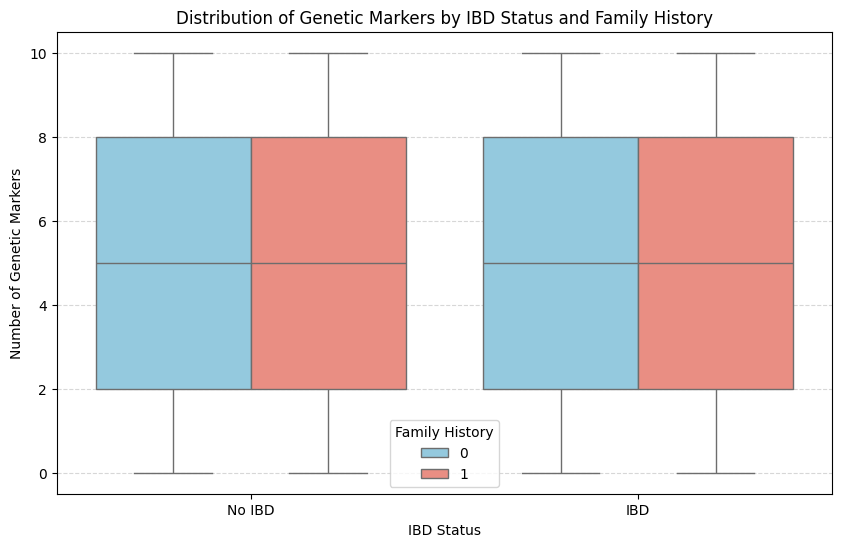

In [195]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Colonoscopy_Result',      
    y='Genetic_Markers',         
    hue='Family_History',         
    palette=['skyblue','salmon']
)

plt.xticks([0,1], ['No IBD','IBD'])
plt.xlabel('IBD Status')
plt.ylabel('Number of Genetic Markers')
plt.title('Distribution of Genetic Markers by IBD Status and Family History')
plt.legend(title='Family History')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

The distribution of Genetic_Markers appears very similar across all groups, regardless of IBD status or family history. The median number of genetic markers and interquartile range are nearly identical for participants with and without IBD. This suggests that, in this dataset, the presence of known genetic markers does not show a clear association with IBD prevalence. Family history also does not appear to modify this distribution.

Chosing the boxplot allows me to visualize the distribution of Genetic_Markers across groups defined by Colonoscopy_Result (IBD vs No IBD) while also examining the effect of Family_History. I split the data using Family_History as a hue to observe how family history in IBD might associate with genetic markers and potentially influencing patients' IBD status. The boxplot provides a clear summary of medians, quartiles, and variability, which helps in identifying patterns or differences between groups.

Limitation: There is identical distributions across groups making it difficult to visually distinguish differences between categories. 